### 2020 ~ 2022 결혼 건수 데이터를 활용해서 결혼 증감율 계산

In [1]:
import pandas as pd
import numpy as np
# encoding = 'euc-kr', index_col = '연령별' --> csv파일 불러오기

In [2]:
data2020 = pd.read_csv('./data/2020.csv', encoding = 'euc-kr', index_col = '연령별')
data2021 = pd.read_csv('./data/2021.csv', encoding = 'euc-kr', index_col = '연령별')
data2022 = pd.read_csv('./data/2022.csv', encoding = 'euc-kr', index_col = '연령별')
data2020.head(10)    #예시 데이터 보고 싶을떄 사용.(10을 넣으면 위에서 부터 앞에서부터 10개를 볼수있음)
                     #tail쓰면 뒤에서부터 볼수있다.

,남편,아내
연령별,,
15,1,16
16,10,27
17,18,80
18,60,471
19,193,921
20,269,1070
21,476,1370
22,789,2045
23,1248,3089


In [3]:
# 데이터 모양 확인
print(data2020.shape)
print(data2021.shape)
print(data2022.shape)

(61, 2)
(62, 2)
(61, 2)


In [4]:
# 데이터 분석을 할 때에는 데이터의 환경을 동일시 시켜주는 것이 좋다.
# 2021년 데이터에 어떤 문제가 있는지 인덱스를 나열해보자.
print(data2020.index)
print(data2021.index)  #2021이 문자 데이터 상태라서 숫자 형태로 바꿔줘야 한다
print(data2022.index)  

RangeIndex(start=15, stop=76, step=1, name='연령별')
Index(['15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26',
       '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38',
       '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50',
       '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62',
       '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74',
       '75', '미상'],
      dtype='str', name='연령별')
RangeIndex(start=15, stop=76, step=1, name='연령별')


In [5]:
# 2021년 데이터에서 "미상" 이라는 데이터를 삭제해보자
data2021.drop('미상', inplace = True) #써서 한번 삭제 했기 때문에 또 실행하면 에러뜸.
print(data2021.index)                #데이터를 먼저 나열하고 온점으로 들어가서 사용할 함수 적기(웬만하면 함수 뒤엔 소괄호가 붙어있다)

Index(['15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26',
       '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38',
       '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50',
       '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62',
       '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74',
       '75'],
      dtype='str', name='연령별')


In [6]:
print(data2020.shape)
print(data2021.shape)  #이렇게 쉐잎을 일치시켜서 데이터 분석을 할 준비를 마친다
print(data2022.shape)

(61, 2)
(61, 2)
(61, 2)


In [7]:
data2021.index #문자열 형태를 띄고 있으므로 -> 숫자 형태로 바꿔주자


Index(['15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26',
       '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38',
       '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50',
       '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62',
       '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74',
       '75'],
      dtype='str', name='연령별')

In [8]:
data2021.index = data2021.index.astype("int64")
data2021.index

Index([15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75],
      dtype='int64', name='연령별')

In [9]:
print(data2020.index)
print(data2021.index)  # 형태가 좀 달라서 같은지 아닌지 증거가 없다

data2020.index == data2021.index #불리안 연산자로 확인

RangeIndex(start=15, stop=76, step=1, name='연령별')
Index([15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75],
      dtype='int64', name='연령별')


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

In [10]:
# 1번 문제. 연령 별 남편 수와 아내의 수를 더한 합계를 우측에 만들어 보자
# 컬럼 : "남편", "아내", "합계'
# data2020, 2021, 2022에 모두 적용

data2020["합계"] = data2020.loc[15:75, "남편":"아내"].sum(axis = 1)  # 선생님 풀이 : data2020["합계"] = data2020.loc[:, "남편":"아내"].sum(axis = 1) 
data2020                                                                         # data2020["합계"] = data2020['남편'] + data2020['아내']
data2021["합계"] = data2021.loc[15:75, "남편":"아내"].sum(axis = 1)
data2021
data2022["합계"] = data2022.loc[15:75, "남편":"아내"].sum(axis = 1)
data2022

print(data2020)
print(data2021)         # 프린트 말고 쉐잎을 찍어보면 잘 만들어졌는지 알수있다. data2020.shape,data2021.shape,data2022.shape
print(data2022)

      남편   아내    합계
연령별                
15     1   16    17
16    10   27    37
17    18   80    98
18    60  471   531
19   193  921  1114
..   ...  ...   ...
71   160   94   254
72   189   81   270
73   166   98   264
74   120   75   195
75    95   55   150

[61 rows x 3 columns]
      남편   아내   합계
연령별               
15     2   12   14
16     6   25   31
17    21   43   64
18    53  208  261
19   141  519  660
..   ...  ...  ...
71   189  136  325
72   188   91  279
73   184   95  279
74   152   97  249
75   114   59  173

[61 rows x 3 columns]
      남편   아내   합계
연령별               
15     2    8   10
16     4   16   20
17    12   49   61
18    51  326  377
19   140  644  784
..   ...  ...  ...
71   137  109  246
72   188  119  307
73   156   99  255
74   145   86  231
75   163   79  242

[61 rows x 3 columns]


In [11]:
# 2번 문제. 연령에 대해서 라벨링 -> 범주화시키기
# bins = [-1, 19, 40, 100], labels = ['청소년', '청년', '중장년']

ages = data2020.index     #인덱스가 같으니까 2020만 써도 됨

bins = [-1, 19, 40, 100]

labels = ['청소년', '청년', '중장년']


cuts = pd.cut(ages, bins, labels = labels)
cuts
data2020["연령대"] = cuts    
data2021["연령대"] = cuts
data2022["연령대"] = cuts
data2020.shape, data2021.shape, data2022.shape

((61, 4), (61, 4), (61, 4))

In [12]:
#연령대가 같은 인원들끼리 합연산 -> 청소년 : x명, 청년 : x명 ...
#groupby() : 범주형 데이터에서 같은 이름을 가지는 데이터끼리 묶어서 연산을 지원

married_2020 = data2020.groupby("연령대").sum() #그룹바이는 연산 함수랑 같이 사용해야 한다
s2020 = married_2020['합계']
s2020

married_2021 = data2021.groupby("연령대").sum()
s2021 = married_2021['합계']
s2021

married_2022 = data2022.groupby("연령대").sum()
s2022 = married_2022['합계']
s2022

연령대
청소년      1252
청년     312035
중장년     69001
Name: 합계, dtype: int64

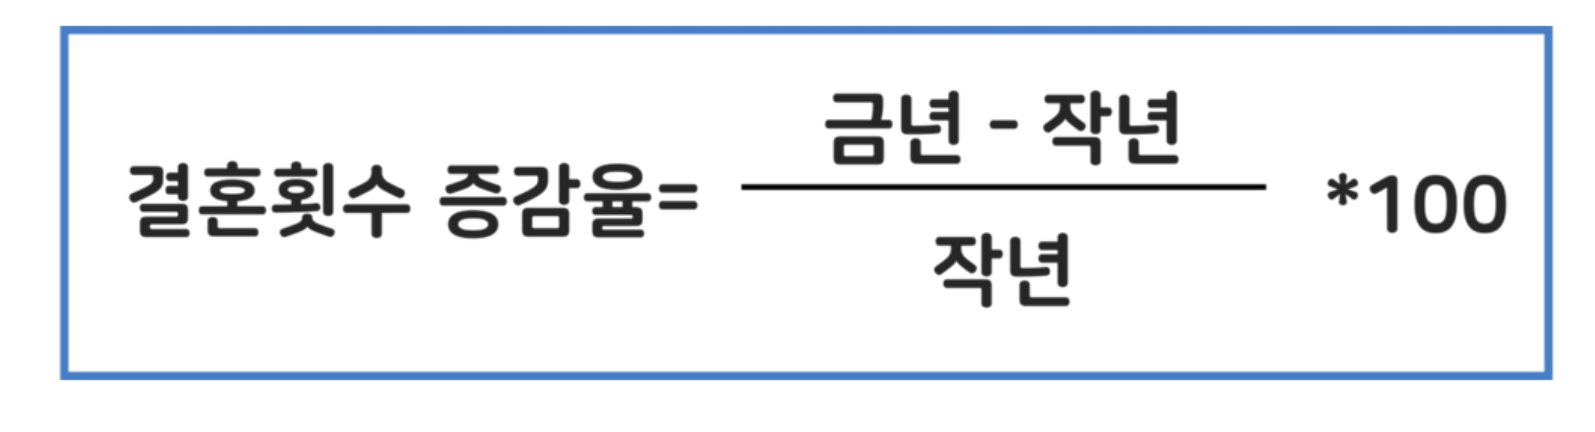

In [13]:
#2020 ~ 2021 증감율 --> married_2020_2021
#2021 ~ 2022 증감율 --> married_2021_2022
married_2020_2021 = round(((s2021.sum() - s2020.sum()) / s2020.sum()) *100, 3)
married_2020_2021 #내풀이. 난 연령대별로 하는건줄 모르고 다 더함

np.float64(-9.866)

In [14]:
married_2021_2022 = round(((s2022.sum() - s2021.sum()) / s2021.sum()) *100, 3)
married_2021_2022

np.float64(-0.443)

In [15]:
married_2020_2021_ =((s2021 - s2020) / s2020) * 100
married_2020_2021_ = round(married_2020_2021_, 2)
married_2021_2022_ =((s2022 - s2021) / s2021) * 100
married_2021_2022_ = round(married_2021_2022_, 2)  #선생님 풀이

In [16]:
s2020.name = "2020년도 합계"
s2021.name = "2021년도 합계"
s2022.name = "2022년도 합계"
married_2020_2021_.name = " 2020_2021 결혼 증감률"
married_2021_2022_.name = " 2021_2022 결혼 증감률"
# 전체 Series 데이터 병합. 기존 데이터와 내가 분석한 데이터를 같이 넣어야 신뢰성이 올라간다.
result = pd.concat([s2020, married_2020_2021_,s2021,married_2021_2022_,s2022], axis = 1)
result

,2020년도 합계,2020_2021 결혼 증감률,2021년도 합계,2021_2022 결혼 증감률,2022년도 합계
연령대,,,,,
청소년,1797,-42.68,1030,21.55,1252
청년,355586,-10.84,317026,-1.57,312035
중장년,68635,-3.94,65932,4.65,69001


In [17]:
# csv파일 형태로 저장   # 한글은 인코딩 방법을 기재해줘야 한다 #데이터의 양이 갈수록 많아 짐에 따라서 엑셀보다 계산이 빠른 파이썬을 활용한다
result.to_csv("./data/결혼증감률계산보고서.csv", encoding = "utf-8")

<Axes: xlabel='연령대'>

C:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
C:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


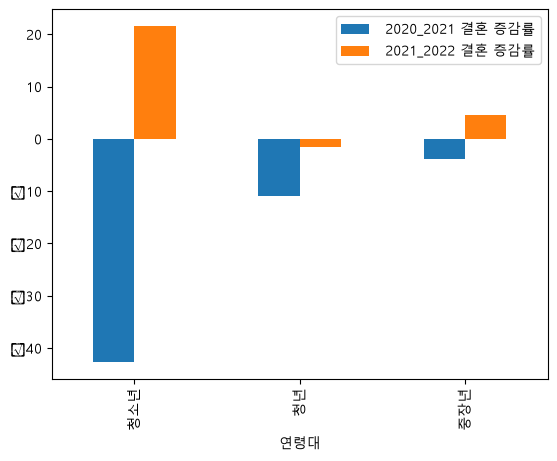

In [18]:
# 그래프 시각화
chart = result.iloc[:, [1, 3]]
chart


import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"

#plot
chart.plot(kind = "bar")